# 05 — Stacked-Bar β Decomposition by PV-Tendency Term

For each lifecycle hour (dh = −13 … +12), project **individual** PV-tendency terms
onto the composite-mean orthogonal basis (built from dh−1) and extract the **β**
(intensification) coefficient.

The result is a stacked bar chart showing how each physical process contributes
to block intensification / de-intensification across the lifecycle.

**Data**: composite NPZ files from `composite_blocking_tempest/onset`  
**Smoothing**: 6° Gaussian  
**Basis**: always from dh−1 (predictive framing)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, glob
from concurrent.futures import ThreadPoolExecutor

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan

## 1  Configuration

In [2]:
DATA_ROOT = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE     = "onset"
SMOOTH_DEG = 3.0
GRID_SP    = 1.5          # grid spacing in degrees
DH_RANGE   = list(range(-13, 13))   # lifecycle hours

print(f"Stage: {STAGE}   Smoothing: {SMOOTH_DEG}°   Grid: {GRID_SP}°")

Stage: onset   Smoothing: 3.0°   Grid: 1.5°


## 2  Helper: load events

In [3]:
from zipfile import BadZipFile

def _load(path):
    try:
        return dict(np.load(path))
    except (BadZipFile, EOFError, OSError):
        return None          # file still being written or corrupt

def load_events(dh):
    """Return list[dict] of all events at a given dh (skips bad files)."""
    sign = "+" if dh >= 0 else ""
    pat = f"{DATA_ROOT}/{STAGE}/dh={sign}{dh}/track_*.npz"
    files = sorted(glob.glob(pat))
    if not files:
        return []
    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(_load, files))
    good = [r for r in results if r is not None]
    n_bad = len(results) - len(good)
    if n_bad:
        print(f"  ⚠ dh={dh}: skipped {n_bad} corrupt/incomplete NPZ files")
    return good

# Quick sanity check at dh=0
_ev0 = load_events(0)
print(f"dh=0 : {len(_ev0)} events, shape={_ev0[0]['pv_anom'].shape}")
X_rel = _ev0[0]["X_rel"]
Y_rel = _ev0[0]["Y_rel"]
x_rel = X_rel[0, :]
y_rel = Y_rel[:, 0]
del _ev0

dh=0 : 1134 events, shape=(29, 49)


## 3  Define individual RHS terms (same as notebook 03)

In [4]:
# Term name → callable(event_dict) → 2-D field
TERMS = {
    r"$\mathrm{d}q/\mathrm{d}t$":        lambda e: e["pv_anom_dt"] + e["pv_bar_dt"],
    r"$-\bar{u}\,q'_x$":                  lambda e: -e["u_bar_pv_anom_dx"],
    r"$-v'\,\bar{q}_y$":                  lambda e: -e["v_anom_pv_bar_dy"],
    r"$-\omega'\,\bar{q}_p$":             lambda e: -e["w_anom_pv_bar_dp"],
    r"$Q$":                                lambda e: e["Q"],
    r"Moist div + vert e-e":               lambda e: -(e["u_div_moist_pv_anom_dx"]
                                                       + e["v_div_moist_pv_anom_dy"]
                                                       + e["w_anom_pv_anom_dp"]),
    r"Rot. eddy":                          lambda e: -(e["u_rot_pv_anom_dx"]
                                                       + e["v_rot_pv_anom_dy"]),
}

TERM_NAMES = list(TERMS.keys())
print("Terms:", TERM_NAMES)

Terms: ['$\\mathrm{d}q/\\mathrm{d}t$', "$-\\bar{u}\\,q'_x$", "$-v'\\,\\bar{q}_y$", "$-\\omega'\\,\\bar{q}_p$", '$Q$', 'Moist div + vert e-e', 'Rot. eddy']


## 4  Lifecycle loop — project every term onto composite basis (dh−1)

In [ ]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)

# Storage: term_name → list of β values (one per dh)
beta_lifecycle = {name: [] for name in TERM_NAMES}
n_events_arr = []

for dh in DH_RANGE:
    # --- Load events at dh and dh-1 ---
    evs = load_events(dh)
    dh_basis = max(dh - 1, -13)
    evs_b = load_events(dh_basis) if dh_basis != dh else evs

    if not evs or not evs_b:
        n_events_arr.append(0)
        for name in TERM_NAMES:
            beta_lifecycle[name].append(np.nan)
        continue

    n_events_arr.append(len(evs))

    # --- Composite-mean basis from dh-1 ---
    pv_anom_mean = np.mean([e["pv_anom"] for e in evs_b], axis=0)
    pv_dx_mean   = np.mean([e["pv_anom_dx"] for e in evs_b], axis=0)
    pv_dy_mean   = np.mean([e["pv_anom_dy"] for e in evs_b], axis=0)

    basis = compute_orthogonal_basis(
        pv_anom_mean, pv_dx_mean, pv_dy_mean,
        x_rel, y_rel,
        mask_negative=True,
        apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
    )

    # --- Project composite-mean of each term ---
    for name, func in TERMS.items():
        fld_mean = np.mean([func(e) for e in evs], axis=0)
        fld_s = smooth(fld_mean)
        p = project_field(fld_s, basis)
        beta_lifecycle[name].append(p["beta"])

    sign = "+" if dh >= 0 else ""
    print(f"dh={sign}{dh:>3d}  N={len(evs):4d}  "
          f"β(dq/dt)={beta_lifecycle[TERM_NAMES[0]][-1]:.3e}")

# Convert to arrays
dh_arr = np.array(DH_RANGE)
n_events_arr = np.array(n_events_arr)
for name in TERM_NAMES:
    beta_lifecycle[name] = np.array(beta_lifecycle[name])

print(f"\nDone.  dh range: {dh_arr[0]} … {dh_arr[-1]}")

dh=-13  N=1134  β(dq/dt)=5.657e-06
dh=-12  N=1134  β(dq/dt)=5.478e-06
dh=-11  N=1134  β(dq/dt)=5.197e-06
  ⚠ dh=-10: skipped 1 corrupt/incomplete NPZ files
dh=-10  N=1134  β(dq/dt)=4.896e-06
  ⚠ dh=-10: skipped 1 corrupt/incomplete NPZ files
dh= -9  N=1134  β(dq/dt)=4.801e-06
dh= -8  N=1134  β(dq/dt)=4.827e-06
dh= -7  N=1134  β(dq/dt)=4.739e-06
dh= -6  N=1134  β(dq/dt)=4.535e-06
  ⚠ dh=-5: skipped 1 corrupt/incomplete NPZ files
dh= -5  N=1134  β(dq/dt)=4.320e-06
  ⚠ dh=-5: skipped 1 corrupt/incomplete NPZ files
dh= -4  N=1134  β(dq/dt)=4.086e-06
dh= -3  N=1134  β(dq/dt)=3.925e-06
  ⚠ dh=-2: skipped 1 corrupt/incomplete NPZ files
dh= -2  N=1134  β(dq/dt)=3.745e-06
  ⚠ dh=-2: skipped 1 corrupt/incomplete NPZ files
dh= -1  N=1134  β(dq/dt)=3.528e-06


## 5  Stacked bar chart — β contributions

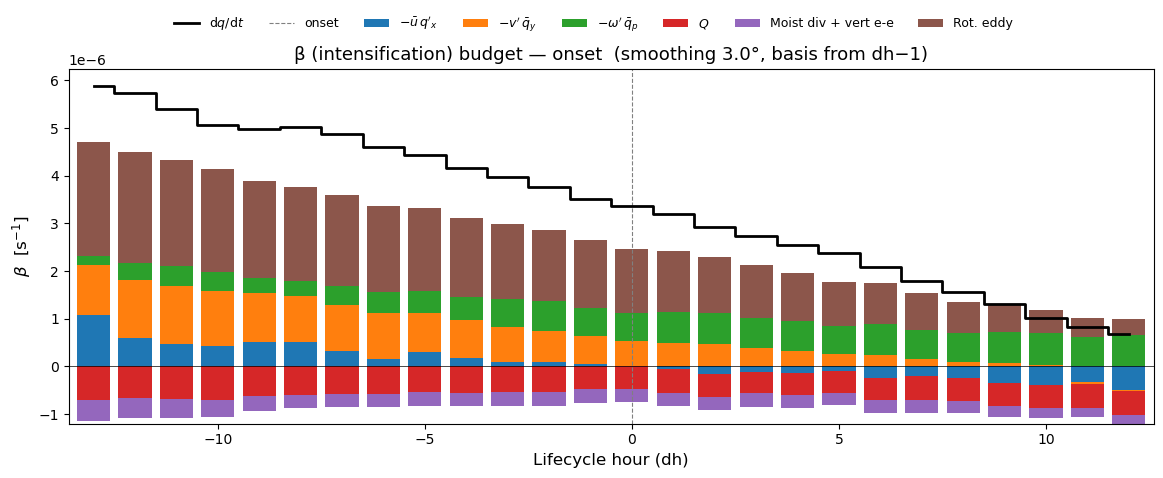

In [ ]:
# Colors for each term (dq/dt gets its own dark marker)
TERM_COLORS = {
    TERM_NAMES[0]: "black",       # dq/dt
    TERM_NAMES[1]: "#1f77b4",     # -ū q'_x  (blue)
    TERM_NAMES[2]: "#ff7f0e",     # -v' q̄_y  (orange)
    TERM_NAMES[3]: "#2ca02c",     # -ω' q̄_p  (green)
    TERM_NAMES[4]: "#d62728",     # Q        (red)
    TERM_NAMES[5]: "#9467bd",     # Moist div (purple)
    TERM_NAMES[6]: "#8c564b",     # Rot. eddy (brown)
}

# Separate RHS terms from the total tendency
rhs_names = TERM_NAMES[1:]   # everything except dq/dt

fig, ax = plt.subplots(figsize=(14, 5))
bar_width = 0.8

# Build positive and negative stacks separately
pos_bottom = np.zeros(len(dh_arr))
neg_bottom = np.zeros(len(dh_arr))

for name in rhs_names:
    vals = beta_lifecycle[name]
    pos_vals = np.where(vals > 0, vals, 0)
    neg_vals = np.where(vals < 0, vals, 0)

    ax.bar(dh_arr, pos_vals, bottom=pos_bottom, width=bar_width,
           color=TERM_COLORS[name], edgecolor="none", label=name)
    ax.bar(dh_arr, neg_vals, bottom=neg_bottom, width=bar_width,
           color=TERM_COLORS[name], edgecolor="none")

    pos_bottom += pos_vals
    neg_bottom += neg_vals

# Overlay dq/dt as a black step line
ax.step(dh_arr, beta_lifecycle[TERM_NAMES[0]], where="mid",
        color="black", lw=2, label=TERM_NAMES[0], zorder=5)

ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="grey", lw=0.8, ls="--", label="onset")
ax.set_xlabel("Lifecycle hour (dh)", fontsize=12)
ax.set_ylabel(r"$\beta$  [s$^{-1}$]", fontsize=12)
ax.set_title(f"β (intensification) budget — {STAGE}  "
             f"(smoothing {SMOOTH_DEG}°, basis from dh−1)", fontsize=13)

# Legend outside the axes, centered below the title like a subtitle
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, 0.95), ncol=len(labels),
           fontsize=9, frameon=False)

ax.set_xlim(dh_arr[0] - 0.6, dh_arr[-1] + 0.6)
fig.subplots_adjust(top=0.82)
plt.show()

## 6  Event-count profile

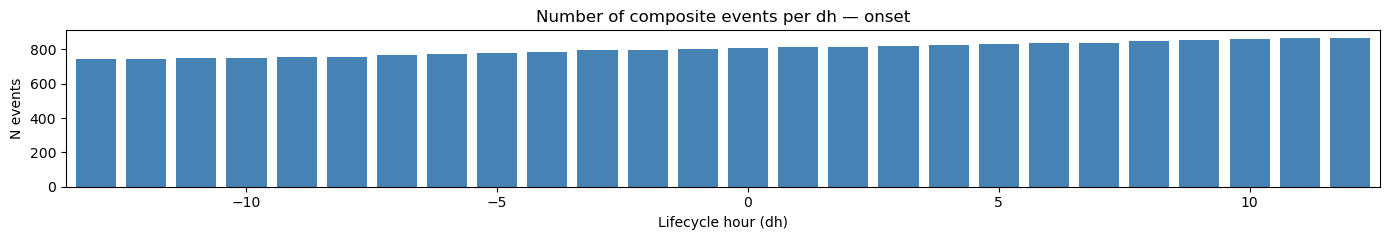

In [ ]:
fig2, ax2 = plt.subplots(figsize=(14, 2.5))
ax2.bar(dh_arr, n_events_arr, color="steelblue", width=0.8)
ax2.set_xlabel("Lifecycle hour (dh)")
ax2.set_ylabel("N events")
ax2.set_title(f"Number of composite events per dh — {STAGE}")
ax2.set_xlim(dh_arr[0] - 0.6, dh_arr[-1] + 0.6)
fig2.tight_layout()
plt.show()

## Summary

- **Stacked bars** show the contribution of each PV-tendency term to the **β (intensification)** coefficient across the blocking lifecycle.
- Positive bars above zero indicate processes that intensify the block (deepen the negative PV anomaly).
- The black step line shows the **total dq/dt** tendency; the stacked RHS terms should approximately reproduce it.
- **Basis**: composite-mean from dh−1 (predictive framing) with 6° Gaussian smoothing.
- **Data**: `composite_blocking_tempest/onset` (all available events).